# **Customer Segmentation Analysis**

## Objective

The objective of this analysis is to segment customers of an e-commerce business into distinct groups based on their purchasing and demographic characteristics. K-Means clustering is used to identify groups of customers with similar behaviors, which can help businesses develop more targeted marketing strategies.

## **Step 1 — Load and inspect**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/content/retail_sales_dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (1000, 9)

Columns:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

Missing Values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Duplicate Rows:
0

Data Types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object


## **Step 2 — Basic data cleaning**

In [5]:
df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].min())
print(df["Date"].max())

2023-01-01 00:00:00
2024-01-01 00:00:00


In [6]:
print("Quantity <= 0:", (df["Quantity"] <= 0).sum())
print("Price <= 0:", (df["Price per Unit"] <= 0).sum())
print("Total Amount <= 0:", (df["Total Amount"] <= 0).sum())

Quantity <= 0: 0
Price <= 0: 0
Total Amount <= 0: 0


In [7]:
df = df.drop_duplicates()

In [8]:
df["Calculated Amount"] = df["Quantity"] * df["Price per Unit"]

print(
    "Amount mismatches:",
    (df["Total Amount"] != df["Calculated Amount"]).sum()
)

Amount mismatches: 0


In [9]:
df.drop(columns=["Calculated Amount"], inplace=True)

## **Step 3 — Descriptive statistics**

In [10]:
print("Average Purchase Value:")
print(df["Total Amount"].mean())

print("\nTotal Revenue:")
print(df["Total Amount"].sum())

print("\nAverage Quantity per Transaction:")
print(df["Quantity"].mean())

print("\nNumber of Unique Customers:")
print(df["Customer ID"].nunique())

print("\nNumber of Transactions:")
print(df["Transaction ID"].nunique())

Average Purchase Value:
456.0

Total Revenue:
456000

Average Quantity per Transaction:
2.514

Number of Unique Customers:
1000

Number of Transactions:
1000


In [11]:
df[["Quantity", "Price per Unit", "Total Amount"]].describe()

,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.000000,1000.000000
mean,2.514000,179.890000,456.000000
std,1.132734,189.681356,559.997632
min,1.000000,25.000000,25.000000
25%,1.000000,30.000000,60.000000
50%,3.000000,50.000000,135.000000
75%,4.000000,300.000000,900.000000
max,4.000000,500.000000,2000.000000


## **Step 4 — Check customer purchase frequency**

In [12]:
customer_transactions = df.groupby("Customer ID")["Transaction ID"].count()

print(customer_transactions.describe())

count    1000.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: Transaction ID, dtype: float64


In [13]:
print(
    "Customers with more than 1 transaction:",
    (customer_transactions > 1).sum()
)

print(
    "Customers with exactly 1 transaction:",
    (customer_transactions == 1).sum()
)

Customers with more than 1 transaction: 0
Customers with exactly 1 transaction: 1000


## **Step 5 — Create clustering dataset**

In [14]:
cluster_df = df[[
    "Customer ID",
    "Age",
    "Quantity",
    "Total Amount"
]].copy()

cluster_df.head()

,Customer ID,Age,Quantity,Total Amount
0,CUST001,34,3,150
1,CUST002,26,2,1000
2,CUST003,50,1,30
3,CUST004,37,1,500
4,CUST005,30,2,100


In [15]:
cluster_df[["Age", "Quantity", "Total Amount"]].describe()

,Age,Quantity,Total Amount
count,1000.00000,1000.000000,1000.000000
mean,41.39200,2.514000,456.000000
std,13.68143,1.132734,559.997632
min,18.00000,1.000000,25.000000
25%,29.00000,1.000000,60.000000
50%,42.00000,3.000000,135.000000
75%,53.00000,4.000000,900.000000
max,64.00000,4.000000,2000.000000


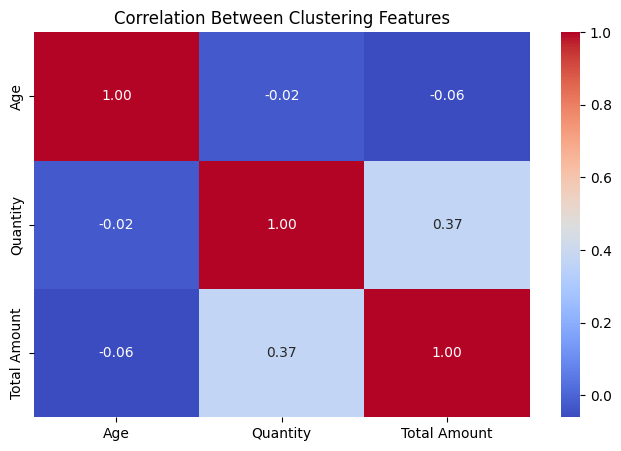

In [16]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    cluster_df[["Age", "Quantity", "Total Amount"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Clustering Features")
plt.show()

## **Step 6 — Standardize the features**

In [17]:
from sklearn.preprocessing import StandardScaler

features = ["Age", "Quantity", "Total Amount"]

X = cluster_df[features]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.54056476,  0.42926498, -0.5467043 ],
       [-1.12559156, -0.45399629,  0.97191876],
       [ 0.62948884, -1.33725757, -0.76109815],
       [-0.32117971, -1.33725757,  0.07861108],
       [-0.83307816, -0.45399629, -0.63603507]])

## **Step 7 — Elbow Method**

In [18]:
from sklearn.cluster import KMeans

inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

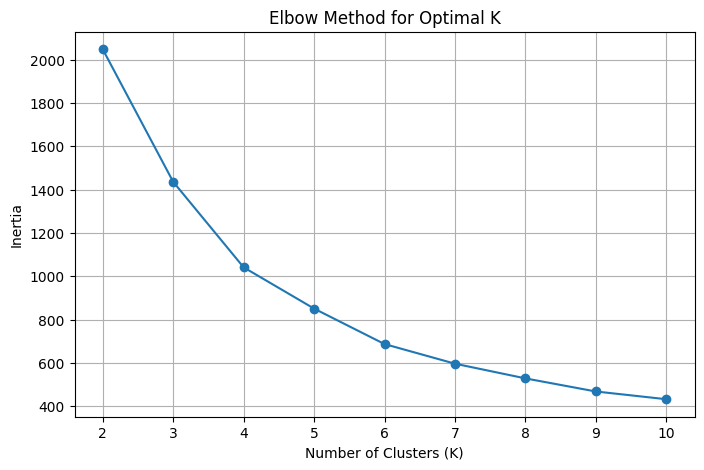

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(K_range, inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.xticks(K_range)
plt.grid(True)
plt.show()

## **Step 8 — Apply K-Means with K = 4**

In [20]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_df["Cluster"] = kmeans.fit_predict(X_scaled)

cluster_df.head()

,Customer ID,Age,Quantity,Total Amount,Cluster
0,CUST001,34,3,150,3
1,CUST002,26,2,1000,1
2,CUST003,50,1,30,0
3,CUST004,37,1,500,1
4,CUST005,30,2,100,1


In [21]:
cluster_counts = cluster_df["Cluster"].value_counts().sort_index()

print(cluster_counts)

Cluster
0    283
1    240
2    228
3    249
Name: count, dtype: int64


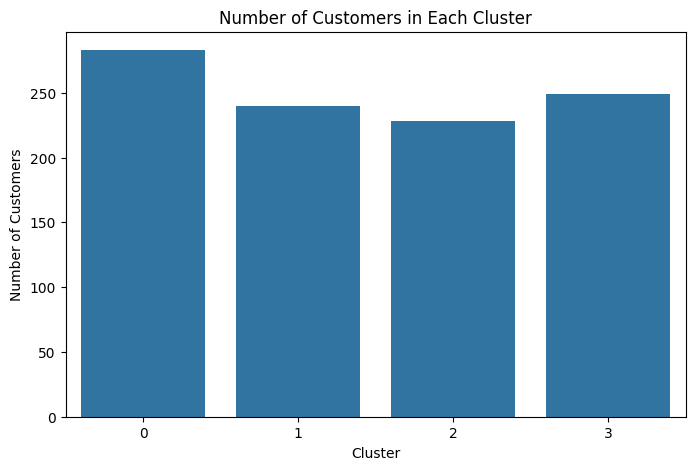

In [22]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=cluster_counts.index,
    y=cluster_counts.values
)

plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.title("Number of Customers in Each Cluster")

plt.show()

## **Step 9 — Profile the clusters**

In [23]:
cluster_profile = cluster_df.groupby("Cluster")[[
    "Age",
    "Quantity",
    "Total Amount"
]].mean().round(2)

cluster_profile

,Age,Quantity,Total Amount
Cluster,,,
0,52.31,1.47,233.06
1,26.83,1.74,211.42
2,39.63,3.39,1344.74
3,44.63,3.64,131.35


## **Step 10 — Visualize the clusters**

*Plot 1 — Quantity vs Total Amount*

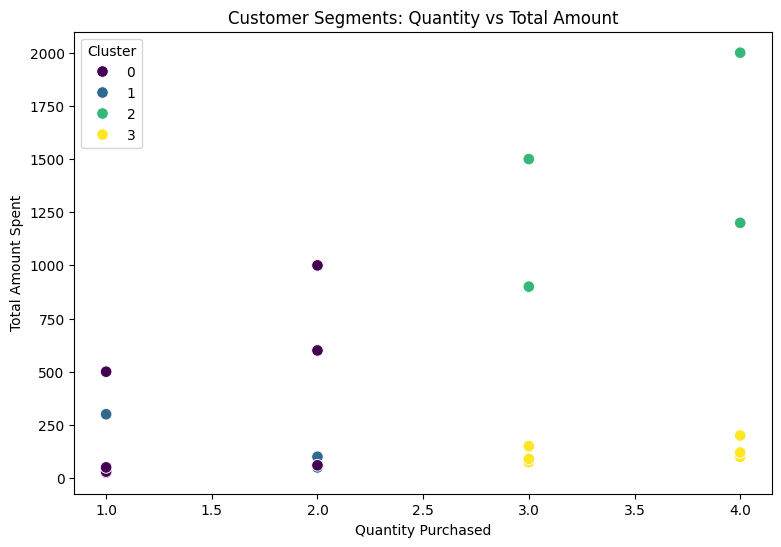

In [24]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=cluster_df,
    x="Quantity",
    y="Total Amount",
    hue="Cluster",
    palette="viridis",
    s=70
)

plt.title("Customer Segments: Quantity vs Total Amount")
plt.xlabel("Quantity Purchased")
plt.ylabel("Total Amount Spent")
plt.legend(title="Cluster")

plt.show()

*Plot 2 — Age vs Total Amount*

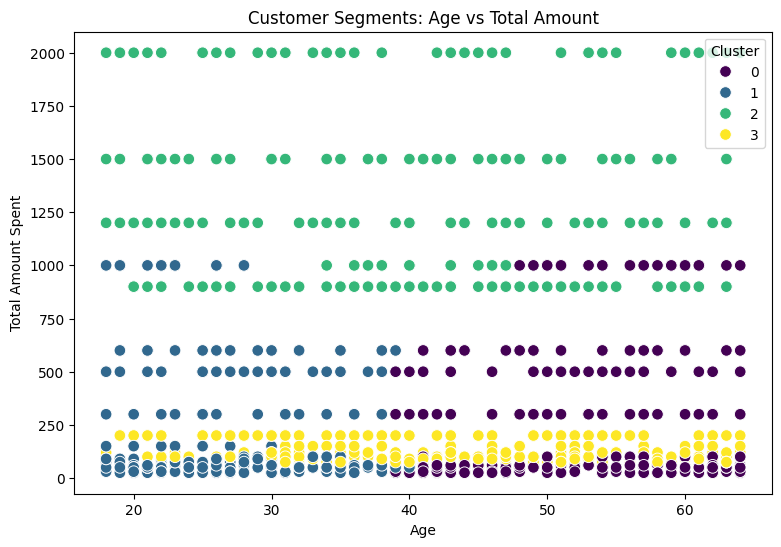

In [25]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=cluster_df,
    x="Age",
    y="Total Amount",
    hue="Cluster",
    palette="viridis",
    s=70
)

plt.title("Customer Segments: Age vs Total Amount")
plt.xlabel("Age")
plt.ylabel("Total Amount Spent")
plt.legend(title="Cluster")

plt.show()

## **Step 11 — Interpret the 4 clusters**

**Cluster 0 — Older, moderate-spending customers**

Highest average age: 52.31
Low quantity: 1.47
Spending is relatively moderate: 233.06

Suggested marketing action:
Offer personalized promotions, loyalty benefits, and products relevant to their purchasing patterns.

**Cluster 1 — Younger, lower-spending customers**

Youngest average age: 26.83
Low quantity: 1.74
Low-to-moderate spending: 211.42

Suggested marketing action:
Use introductory discounts, social-media promotions, bundles, and incentives to encourage larger or repeat purchases.

**Cluster 2 — High-value customers**

This is the most financially significant segment in your dataset.

Average quantity: 3.39
Average spending: 1,344.74
Much higher spending than every other cluster

Suggested marketing action:
Focus on loyalty programs, premium offers, personalized recommendations, and retention campaigns.

**Cluster 3 — High-quantity, low-spending customers**

This one is interesting:

Highest average quantity: 3.64
But average spending is only 131.35
They purchase more items, but those items have relatively low monetary value.

Suggested marketing action:
Use product bundles, cross-selling, and carefully targeted upselling to increase average order value.

## **Step 12 — Creating a nice cluster profile table**

In [26]:
cluster_profile = cluster_df.groupby("Cluster").agg(
    Customers=("Customer ID", "count"),
    Average_Age=("Age", "mean"),
    Average_Quantity=("Quantity", "mean"),
    Average_Spending=("Total Amount", "mean")
).round(2)

cluster_profile

,Customers,Average_Age,Average_Quantity,Average_Spending
Cluster,,,,
0,283,52.31,1.47,233.06
1,240,26.83,1.74,211.42
2,228,39.63,3.39,1344.74
3,249,44.63,3.64,131.35


In [27]:
cluster_profile["Customer Type"] = [
    "Older, Moderate-Spending Customers",
    "Younger, Lower-Spending Customers",
    "High-Value Customers",
    "High-Quantity, Low-Spending Customers"
]

cluster_profile

,Customers,Average_Age,Average_Quantity,Average_Spending,Customer Type
Cluster,,,,,
0,283,52.31,1.47,233.06,"Older, Moderate-Spending Customers"
1,240,26.83,1.74,211.42,"Younger, Lower-Spending Customers"
2,228,39.63,3.39,1344.74,High-Value Customers
3,249,44.63,3.64,131.35,"High-Quantity, Low-Spending Customers"


## **Limitations**

A major limitation of this analysis is that every customer appears only once in the dataset. As a result, purchase frequency, repeat purchases, customer retention, and true customer lifetime value cannot be measured.

The analysis therefore focuses on the available transaction-level and demographic features. Total transaction amount is treated as an indicator of customer value rather than true Customer Lifetime Value.

Future analysis using a dataset containing multiple transactions per customer could apply full RFM analysis and provide more detailed insights into customer loyalty and long-term purchasing behavior.

## **Conclusion**

K-Means clustering was used to segment 1,000 customers based on age, quantity purchased, and total transaction amount. The Elbow Method indicated that four clusters provided a reasonable segmentation of the customer base.

The resulting clusters revealed distinct customer characteristics, including a high-value segment with substantially higher spending, a high-quantity but low-spending segment, and two lower-quantity segments with different age and spending patterns.

These segments can help an e-commerce business develop more targeted marketing strategies, such as loyalty programs for high-value customers, promotional offers for lower-spending customers, and cross-selling or upselling strategies for high-quantity customers.

Although the dataset limits the analysis because each customer has only one transaction, the clustering approach demonstrates how unsupervised machine learning can be used to identify meaningful customer groups from purchasing data.